In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner
import pandas as pd

In [2]:
# Datos
m1  = 0.1180850933
m2  = 0.1619481497
m3  = 0.0771816605
v1   = 0.03492332644
v2   = 0.02776645397
v3   = 0.03505910984
cv12 = 0.001666029016
cv13 = 0.0005078163229
cv23 = 0.0005112105901

# Convertimos los flotantes a fracciones exactas
v1 = sp.Rational(v1)
v2 = sp.Rational(v2)
v3 = sp.Rational(v3)
cv12 = sp.Rational(cv12)
cv13 = sp.Rational(cv13)
cv23 = sp.Rational(cv23)
m1 = sp.Rational(m1)
m2 = sp.Rational(m2)
m3 = sp.Rational(m3)

In [3]:
# Las incognitas
p1, p2, lam, E, V = sp.symbols('p1 p2 lambda E V')

p3 = 1 - p1 - p2

In [4]:
# Definimos el rango del retorno esperado para trazar la frontera eficiente.
E_min = min(m1, m2, m3)
E_max = max(m1, m2, m3)

E_vals = np.linspace(float(E_min), float(E_max), 1000)

In [5]:
# Funcion auxiliar que calcula la varianza dado unos pesos
def varianza(p1_val, p2_val, p3_val):
    return (v1*p1_val**2 + v2*p2_val**2 + v3*p3_val**2
            + 2*cv12*p1_val*p2_val + 2*cv13*p1_val*p3_val + 2*cv23*p2_val*p3_val)

In [6]:
# Formula de la varianza, nuestra f
f = varianza(p1, p2, p3) 

# Esta es la reestriccion, la llamo g
g = m1*p1 + m2*p2 + m3*p3 - E

In [7]:
# Ecuaciones de restricciones
# Solucion interior (los 3 pesos participan)
pol1_3 = sp.diff(f, p1) - lam*sp.diff(g, p1) # Sistema de ecuaciones de Lagrange
pol2_3 = sp.diff(f, p2) - lam*sp.diff(g, p2)
pol3_3 = g
pol4_3 = V -f

G_3 = sp.groebner([pol1_3, pol2_3, pol3_3, pol4_3], [p1, p2, lam, V], order='lex') # Calculamos la base de Gröbner
sol_3 = sp.solve(G_3, (p1, p2, lam, V))

p1_3_func = sp.lambdify(E, sol_3[p1], "numpy")
p2_3_func = sp.lambdify(E, sol_3[p2], "numpy")

# Borde p2 = 0
f_2 = f.subs(p2, 0)
g_2 = g.subs(p2, 0)

pol1_2 = sp.diff(f_2, p1) - lam*sp.diff(g_2, p1) # Sistema de ecuaciones de Lagrange
pol2_2 = g_2

G_2 = sp.groebner([pol1_2, pol2_2], [p1, lam], order='lex') # Calculamos la base de Gröbner
sol_2 = sp.solve(G_2, (p1, lam))

p1_2_func = sp.lambdify(E, sol_2[p1], "numpy")

# Borde p3 = 0
f_1 = f.subs(p2, 1-p1)
g_1 = g.subs(p2, 1-p1)

pol1_1 = sp.diff(f_1, p1) - lam*sp.diff(g_1, p1) # Sistema de ecuaciones de Lagrange
pol2_1 = g_1

G_1 = sp.groebner([pol1_1, pol2_1], [p1, lam], order='lex') # Calculamos la base de Gröbner
sol_1 = sp.solve(G_1, (p1, lam))

p1_1_func = sp.lambdify(E, sol_1[p1], "numpy")

In [8]:
# Funcion que comprueba si una solucion es valida
def pesos_validos(p1_val, p2_val, p3_val, tol=1e-9):
    try:
        p1_val, p2_val, p3_val = float(p1_val), float(p2_val), float(p3_val)
        return (p1_val >= -tol and p2_val >= -tol and p3_val >= -tol)
    except TypeError:
        return False

In [9]:
final_V_vals = []
final_E_vals = []
final_p1 = []
final_p2 = []
final_p3 = []

# Recorremos E
for e in E_vals:
    validos = []
    # Evaluamos los 3 casos
    for (func1, func2) in [(p1_3_func, p2_3_func), (p1_2_func, lambda e: 0), (p1_1_func, lambda e : 1- p1_1_func(e))]:
        p1a = func1(e)
        p2a = func2(e)
        p3a = 1 - p1a - p2a
        if pesos_validos(p1a, p2a, p3a):
            validos.append((varianza(p1a, p2a, p3a), p1a, p2a, p3a))
            
    if validos:
        mejor_caso = min(validos)
        
        final_E_vals.append(e)
        final_V_vals.append(mejor_caso[0]) # Varianza mínima
        final_p1.append(mejor_caso[1])     # Peso 1 óptimo
        final_p2.append(mejor_caso[2])     # Peso 2 óptimo
        final_p3.append(mejor_caso[3])     # Peso 3 óptimo

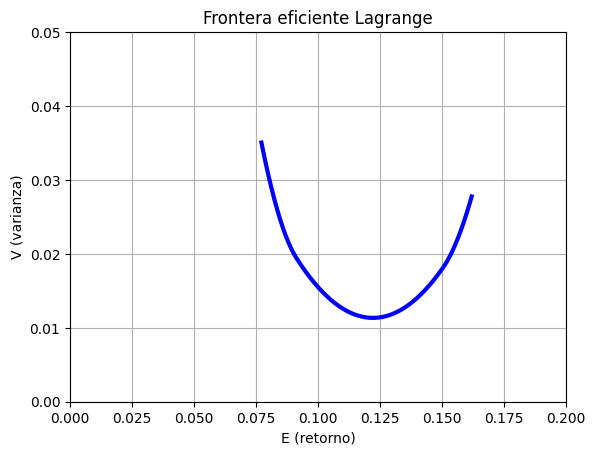

In [10]:
# Ploteamos
plt.plot(final_E_vals, final_V_vals, linewidth=3, color='blue')
plt.xlabel("E (retorno)")
plt.ylabel("V (varianza)")
plt.title("Frontera eficiente Lagrange")
plt.grid(True)
plt.xlim(0, 0.2) 
plt.ylim(0, 0.05)
plt.show()

Se han generado numerosas combinaciones aleatorias de pesos para los activos. Total: 2000 combinaciones.


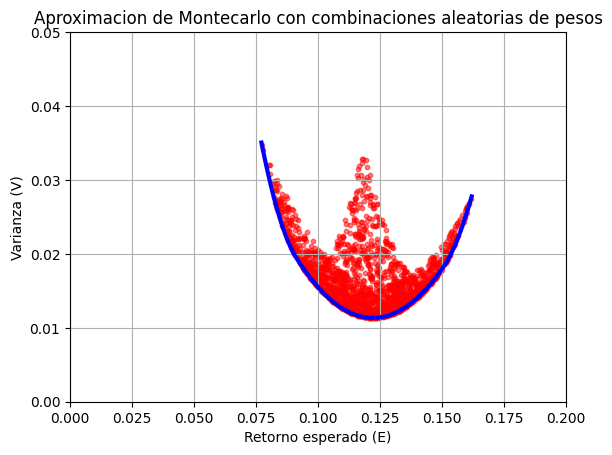

In [11]:
N = 2000
lista_monteCarlo = []

# Este comando da solamente los pesos que suman 1 y nos da valores aleatorios, que son carteras aleatorias
pesos = np.random.dirichlet(np.ones(3), size=N)

# Guardamos los pesos
for i in range(N):
    lista_monteCarlo.append((pesos[i][0], pesos[i][1], pesos[i][2]))
# Print para el tamaño, y ademas debbing para ver que se estan generando las combinaciones
print(f"Se han generado numerosas combinaciones aleatorias de pesos para los activos. Total: {N} combinaciones.")
plt.figure()

# Calulamos el retorno esperado y la varianza para cada combinacion de pesos, y los graficamos, para ver que caen debajo de la frontera eficiente
for i in range(len(lista_monteCarlo)):
    p1Carlo, p2Carlo, p3Carlo = lista_monteCarlo[i]
    E_random = m1*p1Carlo + m2*p2Carlo + m3*p3Carlo
    V_random = v1*p1Carlo**2 + v2*p2Carlo**2 + v3*p3Carlo**2 + 2*cv12*p1Carlo*p2Carlo + 2*cv13*p1Carlo*p3Carlo + 2*cv23*p2Carlo*p3Carlo
    plt.scatter(E_random, V_random, color='red', s=10, alpha=0.5)

# Hacemos el plot similar anterior, pero con un scatterplot (puntos de (E,V)) para ver que se aproxima bien
plt.xlabel("Retorno esperado (E)")
plt.ylabel("Varianza (V)")
plt.title("Aproximacion de Montecarlo con combinaciones aleatorias de pesos")
plt.plot(final_E_vals, final_V_vals, linewidth=3, color="blue")
plt.xlim(0, 0.2)
plt.ylim(0, 0.05)

plt.grid(True)

plt.savefig("aproxLagrange.png", dpi=300, bbox_inches="tight")
plt.show()


In [12]:
E_res = np.array(final_E_vals, dtype=float)
V_res = np.array(final_V_vals, dtype=float)
p1_res = np.array(final_p1, dtype=float)
p2_res = np.array(final_p2, dtype=float)
p3_res = np.array(final_p3, dtype=float)

In [13]:
# Sacamos el excel filtrado 
df_ok = pd.DataFrame({
    "E (Retorno)":    E_res,
    "V (Varianza)":   V_res,
    "Peso ETF1 (p1)": p1_res,
    "Peso ETF2 (p2)": p2_res,
    "Peso ETF3 (p3)": p3_res,
})

df_ok.to_excel("lagrange_filtrado.xlsx", index=False)